In [1]:
#For EDA, we are importing the Univariate analysis .py file.
from Univariate import Univariate

In [2]:
#Assign the variable to the class Univariate
obj= Univariate()

In [3]:
#Importing the stock data from nsepy
from nsepy import get_history as gh
import datetime as dt # 1 hr data only not less than that.
import yfinance as yf
import pandas as pd
import numpy as np

In [4]:
#Downloading Reliance data from yfinance
start = dt.datetime(2023,1,1)
end = dt.datetime(2023,7,1)
stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [5]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 122 entries, 2023-01-02 to 2023-06-30
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   122 non-null    float64
 1   (High, RELIANCE.NS)    122 non-null    float64
 2   (Low, RELIANCE.NS)     122 non-null    float64
 3   (Open, RELIANCE.NS)    122 non-null    float64
 4   (Volume, RELIANCE.NS)  122 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.7 KB


In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2023-06-23,1147.974976,1156.488600,1146.719570,1154.434333,6628570
2023-06-26,1139.210083,1148.271535,1136.083100,1144.436976,12641159


In [7]:
#Checking Low of reliance data
low=stk_data["Low"]
low

Ticker,RELIANCE.NS
Date,
2023-01-02,1163.244669
2023-01-03,1163.062148
2023-01-04,1147.632506
2023-01-05,1143.067616
2023-01-06,1149.595501
...,...
2023-06-23,1146.719570
2023-06-26,1136.083100
2023-06-27,1135.147420


In [8]:
#Assigning the Reliance stk_data as dataset
dataset=stk_data
dataset.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [9]:
# To Get the first level of the column index.
dataset.columns = dataset.columns.get_level_values(0)
dataset.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [10]:
quan,qual = obj.quanQual(dataset)

In [11]:
quan

['Close', 'High', 'Low', 'Open', 'Volume']

In [12]:
qual

[]

In [13]:
des_data = obj.Descriptive(quan,dataset)

In [14]:
des_data

,Close,High,Low,Open,Volume
Mean,1101.50931,1110.478161,1093.310518,1103.458407,13045123.737705
Median,1109.366638,1116.533652,1100.830118,1109.252658,11680332.5
Mode,1004.863159,1013.422486,995.162593,1011.140007,5316175
Q1:25%,1069.143524,1077.411915,1059.99074,1072.327685,9243317.25
Q2:50%,1109.366638,1116.533652,1100.830118,1109.252658,11680332.5
Q3:75%,1132.813538,1141.224406,1125.06438,1136.30002,15457766.25
99%,1176.430652,1186.078639,1163.225488,1177.770672,32383789.1
Q4:100%,1185.430298,1189.630256,1168.722653,1189.630256,34014213.0
IQR,63.670013,63.81249,65.073641,63.972335,6214449.0
1.5 rule,95.50502,95.718736,97.610461,95.958503,9321673.5


In [15]:
des_data["Low"]

Mean        1093.310518
Median      1100.830118
Mode         995.162593
Q1:25%       1059.99074
Q2:50%      1100.830118
Q3:75%       1125.06438
99%         1163.225488
Q4:100%     1168.722653
IQR           65.073641
1.5 rule      97.610461
Lesser       962.380279
Greater     1222.674841
Min          995.162593
Max         1168.722653
Name: Low, dtype: object

In [16]:
des_data["High"]

Mean        1110.478161
Median      1116.533652
Mode        1013.422486
Q1:25%      1077.411915
Q2:50%      1116.533652
Q3:75%      1141.224406
99%         1186.078639
Q4:100%     1189.630256
IQR            63.81249
1.5 rule      95.718736
Lesser       981.693179
Greater     1236.943141
Min         1013.422486
Max         1189.630256
Name: High, dtype: object

In [17]:
#for other percentile
np.percentile(dataset["Low"],99)

1163.2254877470612

In [18]:
np.percentile(dataset["High"],80)

1145.7060426461207

C:\AI Course\Time series Analysis\Univariate.py:65: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax= sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=1110.478,Standard Deviation=41.824
The area between range(1100,1130):0.2789065533333286


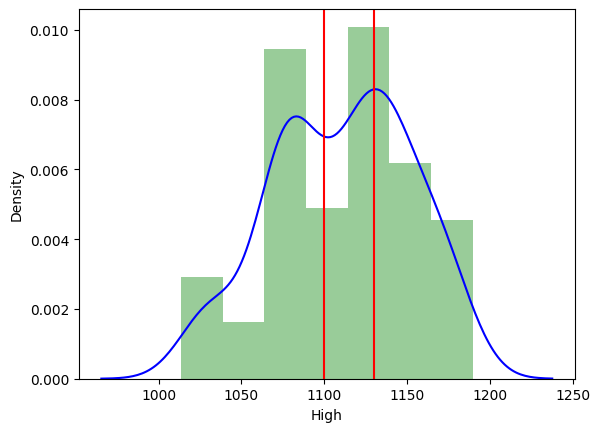

In [19]:
#Probability distribution function analysis
pdf= obj.get_pdf_probability(dataset["High"],1100,1130)

C:\AI Course\Time series Analysis\Univariate.py:91: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True) # to plot the distribution of data using z_score


Mean of z_score: -0.0
Standard deviation of z_score: 0.9959


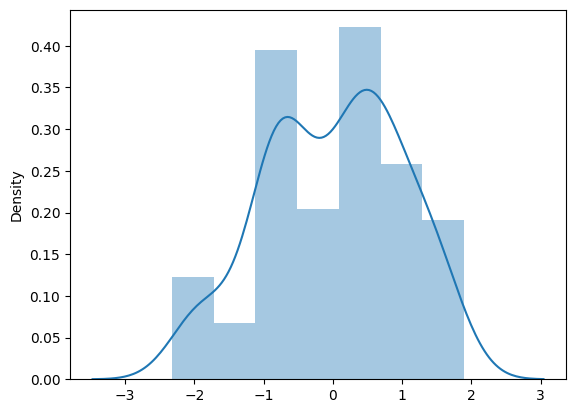

In [20]:
#Standard normal distribution:
norm_dis = obj.StdNBgraph(dataset["High"])

In [26]:
#Checking support and resistance for the stock using freq table
frq = obj.freqTable("High",dataset)
frq

,Unique_values,Frequency,Relative_freq,Cumulative
0,1177.304802,1,0.819672,0.819672
1,1121.612227,1,0.819672,1.639344
2,1141.058816,1,0.819672,2.459016
3,1143.318593,1,0.819672,3.278689
4,1135.489745,1,0.819672,4.098361
...,...,...,...,...
117,1109.286817,1,0.819672,96.721311
118,1116.955869,1,0.819672,97.540984
119,1118.302630,1,0.819672,98.360656
120,1117.275487,1,0.819672,99.180328


In [27]:
frq.sort_values(by="Frequency",ascending=False)

,Unique_values,Frequency,Relative_freq,Cumulative
0,1177.304802,1,0.819672,0.819672
91,1072.767055,1,0.819672,75.409836
89,1157.858149,1,0.819672,73.770492
88,1163.130627,1,0.819672,72.950820
87,1187.804182,1,0.819672,72.131148
...,...,...,...,...
36,1156.488600,1,0.819672,30.327869
35,1148.271535,1,0.819672,29.508197
34,1145.578264,1,0.819672,28.688525
33,1158.519991,1,0.819672,27.868852


In [30]:
#checking which frequency has occured 2 times.
fhs= frq[frq["Frequency"]==2]["Unique_values"].sort_values(ascending=False)
fhs

Series([], Name: Unique_values, dtype: float64)

In [34]:
frql = obj.freqTable("Low",dataset)
frql

,Unique_values,Frequency,Relative_freq,Cumulative
0,1163.244669,1,0.819672,0.819672
1,1107.985695,1,0.819672,1.639344
2,1118.485060,1,0.819672,2.459016
3,1128.984605,1,0.819672,3.278689
4,1121.383968,1,0.819672,4.098361
...,...,...,...,...
117,1084.202367,1,0.819672,96.721311
118,1101.229549,1,0.819672,97.540984
119,1100.202545,1,0.819672,98.360656
120,1100.430688,1,0.819672,99.180328


In [35]:
frql.sort_values(by="Frequency",ascending=False)

,Unique_values,Frequency,Relative_freq,Cumulative
0,1163.244669,1,0.819672,0.819672
91,1056.127767,1,0.819672,75.409836
89,1143.067616,1,0.819672,73.770492
88,1149.595501,1,0.819672,72.950820
87,1161.030607,1,0.819672,72.131148
...,...,...,...,...
36,1146.719570,1,0.819672,30.327869
35,1136.083100,1,0.819672,29.508197
34,1135.147420,1,0.819672,28.688525
33,1140.260037,1,0.819672,27.868852


In [36]:
fls= frql[frql["Frequency"]==2]["Unique_values"].sort_values(ascending=False)
fls

Series([], Name: Unique_values, dtype: float64)